### Taking information from t-1 and t0

In [270]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                                     # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal                                     # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore

### Importing dataset

In [271]:
lead_time = 1
data = pd.read_csv(f"/home/mendrika/mendrika-phd/data/other-location/cleaned/Dakar/t-1-and-t0/train-data-Dakar-lt{lead_time + 1}-with-t-1.csv", index_col=False)
test_data = pd.read_csv(f"/home/mendrika/mendrika-phd/data/other-location/cleaned/Dakar/t-1-and-t0/test-data-Dakar-lt{lead_time + 1}-with-t-1.csv", index_col=False)

#### combining dataset and doing some exploratory analysis

In [272]:
data = data.dropna()
test_data = test_data.dropna()

In [273]:
original_test_data = test_data.copy()

In [274]:
data

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size2_t1,size3_t1,size4_t1,size5_t1,ds1_t1,ds2_t1,ds3_t1,ds4_t1,ds5_t1,Cb_dakar_t2
0,2004,6,1,17,45,12.08,-8.22,10.06,-8.13,14.00,...,13500.0,0.0,0.0,0.0,304.60,343.29,430.00,430.00,430.00,0.0
1,2004,6,1,18,0,12.13,-8.18,10.02,-8.31,14.00,...,12825.0,0.0,0.0,0.0,305.56,338.74,430.00,430.00,430.00,0.0
2,2004,6,1,18,15,12.17,-8.18,10.02,-8.45,14.00,...,24875.0,12550.0,0.0,0.0,308.42,329.56,336.86,430.00,430.00,0.0
3,2004,6,1,18,30,12.00,-8.94,12.13,-8.27,14.00,...,21100.0,12900.0,0.0,0.0,308.42,325.22,332.34,430.00,430.00,0.0
4,2004,6,1,18,45,12.04,-8.85,10.60,-8.18,14.00,...,14350.0,8075.0,0.0,0.0,289.21,308.42,329.63,430.00,430.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83956,2019,9,30,3,0,13.16,-14.38,11.59,-15.86,14.00,...,24125.0,700.0,1650.0,0.0,80.61,92.20,108.00,115.69,430.00,0.0
83957,2019,9,30,3,15,13.16,-14.20,11.55,-15.99,14.00,...,26875.0,0.0,0.0,0.0,76.37,126.50,430.00,430.00,430.00,0.0
83958,2019,9,30,3,30,13.21,-14.20,11.50,-16.13,12.22,...,6175.0,4050.0,14625.0,0.0,74.28,86.83,113.65,125.51,430.00,0.0
83959,2019,9,30,4,0,12.26,-16.13,13.39,-14.20,13.03,...,2000.0,2300.0,14650.0,0.0,72.47,83.35,91.27,109.44,430.00,0.0


#### Choosing field to include in the data

In [275]:
target_index = f"Cb_dakar_t{lead_time + 1}"

t0 = "year,month,day,hour,minute,"
t1 = "year_t1,month_t1,day_t1,hour_t1,minute_t1,"
loc = wp = ds = sz = "" 
loc_t1 = wp_t1 = ds_t1 = sz_t1 = "" 

for i in range(1, 6):
    loc += f"lat{i},lon{i},"
    wp += f"wp{i},"
    ds += f"ds{i},"
    sz += f"size{i},"
    loc_t1 += f"lat{i}_t1,lon{i}_t1,"
    wp_t1 += f"wp{i}_t1,"
    ds_t1 += f"ds{i}_t1,"
    sz_t1 += f"size{i}_t1,"

field = t0 + loc + wp + sz + ds + t1 + loc_t1 + wp_t1 + sz_t1 + ds_t1 + target_index

In [276]:
field = field.split(',')
data = data[field]
test_data = test_data[field]

In [277]:
data.describe()

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size2_t1,size3_t1,size4_t1,size5_t1,ds1_t1,ds2_t1,ds3_t1,ds4_t1,ds5_t1,Cb_dakar_t2
count,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000,...,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000,83961.000000
mean,2011.345244,7.673718,16.089553,12.789652,22.262836,12.989010,-13.479035,12.945735,-13.417633,13.090085,...,7940.721287,6897.726028,5809.000905,4883.544443,120.751690,151.743560,194.442560,236.414729,274.532828,0.090244
std,4.590482,1.058837,8.838787,7.362555,16.759581,1.879273,2.661476,1.869138,2.659021,1.774999,...,7861.592174,7688.665744,7380.181848,7091.231182,70.688289,74.009953,102.038832,118.598225,124.560589,0.286533
min,2004.000000,6.000000,1.000000,0.000000,0.000000,10.020000,-17.970000,10.020000,-17.970000,10.020000,...,75.000000,0.000000,0.000000,0.000000,0.000000,6.710000,12.530000,13.150000,24.760000,0.000000
25%,2007.000000,7.000000,9.000000,6.000000,0.000000,11.500000,-15.720000,11.460000,-15.630000,11.680000,...,2200.000000,1400.000000,500.000000,0.000000,63.390000,93.560000,120.280000,144.500000,167.000000,0.000000
50%,2011.000000,8.000000,16.000000,15.000000,15.000000,12.710000,-13.700000,12.620000,-13.610000,13.030000,...,5475.000000,4350.000000,3125.000000,1950.000000,115.940000,147.050000,175.160000,208.470000,252.730000,0.000000
75%,2015.000000,9.000000,24.000000,19.000000,30.000000,14.290000,-11.410000,14.240000,-11.370000,14.020000,...,11100.000000,9775.000000,8350.000000,7000.000000,167.610000,200.810000,249.090000,309.480000,430.000000,0.000000
max,2019.000000,9.000000,31.000000,23.000000,45.000000,17.970000,-8.040000,17.970000,-8.040000,17.970000,...,75775.000000,78750.000000,83900.000000,85250.000000,340.030000,354.200000,430.000000,430.000000,430.000000,1.000000


### Exploratory data analysis

In [278]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [279]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [280]:
to_scale = wp + wp_t1 + sz + sz_t1 + ds + ds_t1

In [281]:
transform = True
t0t1 = t0 + t1
if transform:
    data = log_transform(data, to_scale.split(',')[:-1])    
    data = sqrt_transform(data, t0t1.split(',')[:-1])
    test_data = log_transform(test_data, to_scale.split(',')[:-1])    
    test_data = sqrt_transform(test_data, t0t1.split(',')[:-1])

#### splitting the data  into training and testing before oversampling the training set

In [282]:
train, validation = train_test_split(data, test_size=0.2, random_state=12)

In [283]:
train

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size2_t1,size3_t1,size4_t1,size5_t1,ds1_t1,ds2_t1,ds3_t1,ds4_t1,ds5_t1,Cb_dakar_t2
61653,44.888751,2.828427,4.795832,4.123106,3.872983,14.06,-17.12,15.68,-17.88,16.22,...,6.980076,8.486734,9.400961,8.481566,1.609438,3.279783,3.761433,4.108083,4.120986,1.0
17510,44.799554,2.645751,4.582576,2.000000,6.708204,11.77,-16.89,12.04,-16.35,10.74,...,9.743905,-18.420681,-18.420681,-18.420681,4.706372,5.058346,6.063785,6.063785,6.063785,0.0
48962,44.855323,3.000000,4.358899,3.000000,0.000000,13.75,-15.00,13.25,-14.92,11.82,...,9.132379,-18.420681,-18.420681,-18.420681,4.423408,5.718999,6.063785,6.063785,6.063785,0.0
50831,44.866469,2.645751,3.464102,3.464102,6.708204,10.60,-9.93,11.55,-9.88,10.38,...,9.135078,7.707512,7.955074,-18.420681,5.088152,5.132558,5.355123,5.630100,6.063785,0.0
41532,44.844175,2.828427,4.123106,1.732051,3.872983,16.04,-16.13,15.81,-14.60,14.11,...,9.573246,7.423568,8.665613,9.762788,3.846738,4.207822,4.294970,4.644872,4.746409,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75011,44.922155,2.645751,2.000000,4.123106,0.000000,10.92,-9.70,12.53,-17.07,10.65,...,7.362011,8.022897,9.659822,8.857230,5.134503,5.256714,5.400513,5.696859,5.726848,0.0
36482,44.833024,3.000000,1.732051,2.236068,3.872983,17.16,-11.37,10.11,-14.47,14.06,...,6.774224,7.438384,7.509335,-18.420681,5.219058,5.606353,5.613566,5.771939,6.063785,0.0
40177,44.844175,2.645751,4.472136,1.000000,0.000000,12.62,-15.59,14.82,-10.69,11.19,...,9.703511,8.775704,7.047517,8.055158,4.618974,4.692448,4.882044,4.917203,5.390577,0.0
19709,44.799554,2.828427,5.385165,4.472136,6.708204,16.76,-10.74,17.30,-9.30,14.00,...,8.094073,8.902456,7.522941,-18.420681,5.463450,5.576214,5.654417,5.667672,6.063785,0.0


In [284]:
neg, pos = train[target_index].value_counts()
total = neg + pos
print(f"Negative: {neg} and Positive: {pos}. That is {pos/total:.2f} of the total.")

Negative: 61119 and Positive: 6049. That is 0.09 of the total.


In [285]:
x_train = train.drop([target_index], axis=1).to_numpy()
y_train = train[target_index]

x_val = validation.drop([target_index], axis=1).to_numpy()
y_val = validation[target_index]

x_test = test_data.drop([target_index], axis=1).to_numpy()
y_test = test_data[target_index]

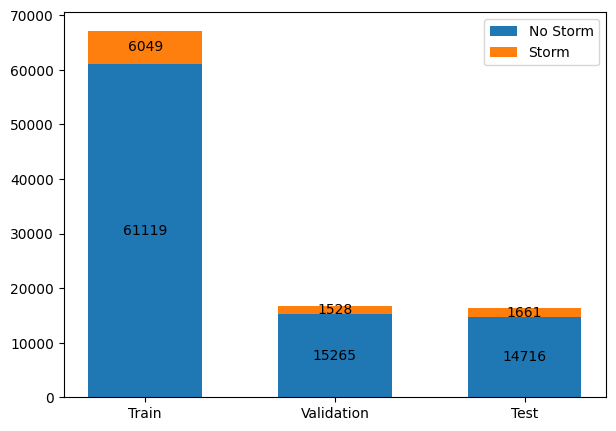

In [286]:
type = ('Train', 'Validation', 'Test')

storm_counts = {
    'No Storm': np.array([y_train.value_counts()[0], y_val.value_counts()[0], y_test.value_counts()[0]]),
    'Storm': np.array([y_train.value_counts()[1], y_val.value_counts()[1] , y_test.value_counts()[1]]),
}
width = 0.6  # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(7,5))
bottom = np.zeros(3)

for mode, count in storm_counts.items():
    p = ax.bar(type, count, width, label=mode, bottom=bottom)
    bottom += count

    ax.bar_label(p, label_type='center')

ax.legend()

plt.show()

#### Normalising the features

In [287]:
# normalise data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [288]:
dump(scaler, f'Dakar-lt{lead_time}-fc-t0-t-1.bin', compress=True)

['Dakar-lt1-fc-t0-t-1.bin']

In [289]:
initial_bias = np.log(pos/neg)
output_bias = tf.keras.initializers.Constant(value=initial_bias)

model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(len(data.keys())-1,)),
  tf.keras.layers.Dense(32, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Dropout(0.2),    
  tf.keras.layers.Dense(16, activation='relu'),
  tf.keras.layers.Dense(8, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid', bias_initializer=output_bias)
])

l1_reg = tf.keras.regularizers.L1(0.1)
for layer in model.layers[:]:
  layer.kernel_regularizer = l1_reg

cl_thresholds = 0.3

METRICS = [
      tf.keras.metrics.MeanSquaredError(name='bs'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.TrueNegatives(name='tn'),                        
      tf.keras.metrics.Recall(name='recall', thresholds = cl_thresholds),
      tf.keras.metrics.Precision(name='precision', thresholds = cl_thresholds),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR'), 
      tf.keras.metrics.F1Score(name = 'f1_score',  threshold = cl_thresholds),
]


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=METRICS)

In [290]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [291]:
EPOCHS = 500
BATCH_SIZE = 1024

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", 
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)


# train the model
model_history = model.fit(x_train, 
                          y_train, 
                          epochs=EPOCHS, 
                          callbacks = [early_stopping],
                          batch_size = BATCH_SIZE,         
                          validation_data=(x_val, y_val),
                        )

Epoch 1/500


66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - auc: 0.5233 - bs: 0.0841 - f1_score: 0.0000e+00 - loss: 0.3248 - prc: 0.1232 - precision: 0.0000e+00 - recall: 0.0000e+00 - tn: 31630.0742 - tp: 0.0000e+00 - val_auc: 0.8783 - val_bs: 0.0718 - val_f1_score: 0.0026 - val_loss: 0.2371 - val_prc: 0.4173 - val_precision: 1.0000 - val_recall: 0.0013 - val_tn: 15265.0000 - val_tp: 0.0000e+00
Epoch 2/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.8790 - bs: 0.0670 - f1_score: 0.3232 - loss: 0.2216 - prc: 0.4212 - precision: 0.5241 - recall: 0.2609 - tn: 31421.4785 - tp: 341.3881 - val_auc: 0.9312 - val_bs: 0.0520 - val_f1_score: 0.5987 - val_loss: 0.1729 - val_prc: 0.5974 - val_precision: 0.5579 - val_recall: 0.6459 - val_tn: 15047.0000 - val_tp: 498.0000
Epoch 3/500
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9286 - bs: 0.0518 - f1_score: 0.5814 - loss: 0.1728 - prc: 0.5894 - precision: 0.5612 - recall: 0.6036 - tn: 31146.8965 - tp: 1121.5074 - val_auc: 0.9456 - val_bs: 0.0452 - val_f1_score

In [292]:
def class_prediction(x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [293]:
def plot_cm(y, y_hat, classification_threshold):
    # compute the contingency table    
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

In [294]:
def plot_metrics(history):
  metrics = ['loss', 'bs', 'recall', 'precision']
  for n, metric in enumerate(metrics):
    name = metric.replace("_"," ").capitalize()
    plt.subplot(2,2,n+1)
    plt.plot(history.epoch, history.history[metric], color="red", label='Train')
    plt.plot(history.epoch, history.history['val_'+metric],
             color=colors[0], linestyle="--", label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    if metric == 'loss':
      plt.ylim([0, plt.ylim()[1]])
    elif metric == 'auc':
      plt.ylim([0.5,1])
    else:
      plt.ylim([0,1])

    plt.legend()

### Performance on training data

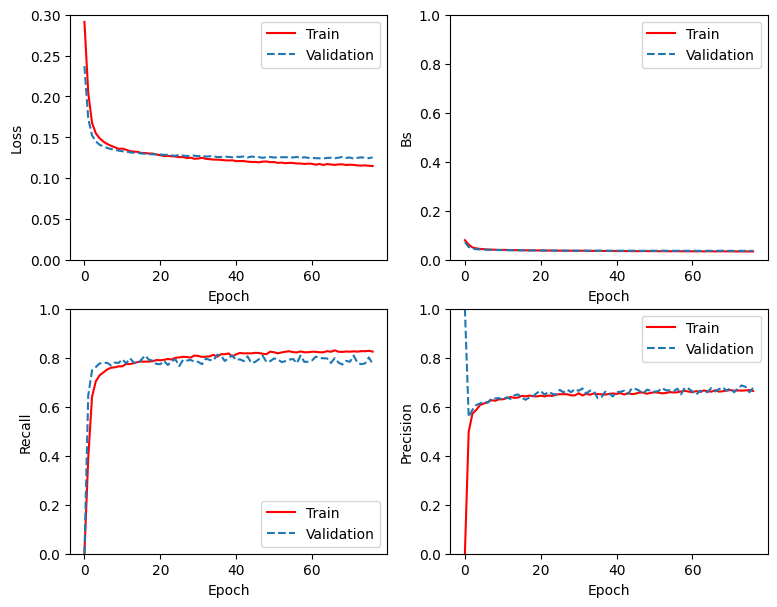

In [295]:
plot_metrics(model_history)

### Performance on testing data

In [296]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
0.06638439


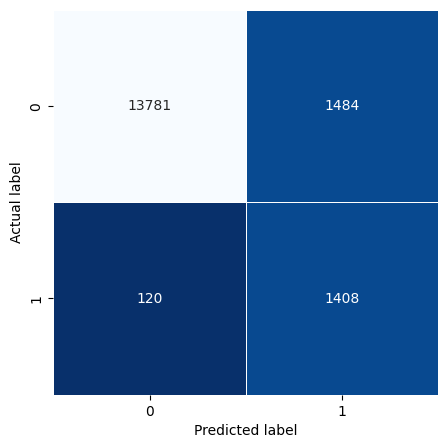

In [297]:
y_hat_val, auc_val, bs_val = class_prediction(x_val, y_val)
classification_threshold_val = cutoff_youdens_j(*roc_curve(y_val, y_hat_val))
print(classification_threshold_val)
plot_cm(y_val, y_hat_val, classification_threshold=classification_threshold_val)

In [298]:
average_precision_score(y_val, y_hat_val)

0.7860715269043455

512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


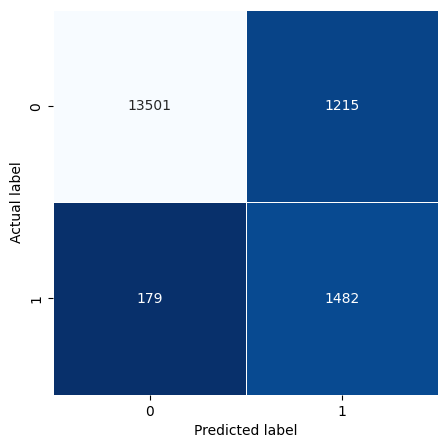

In [299]:
y_hat_test, auc_test, bs_test = class_prediction(x_test, y_test)
classification_threshold = cutoff_youdens_j(*roc_curve(y_test, y_hat_test))
plot_cm(y_test, y_hat_test, classification_threshold=classification_threshold_val)

In [300]:
average_precision_score(y_test, y_hat_test)

0.7792967865988542

In [301]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

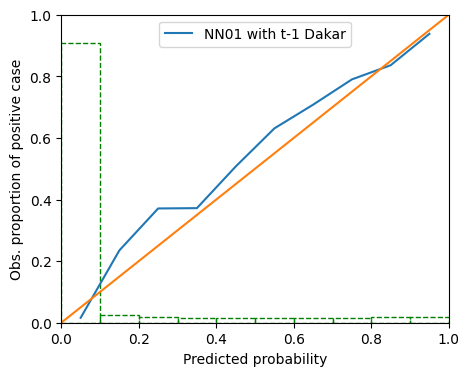

In [302]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, y_hat_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"NN01 with t-1 Dakar")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

In [308]:
model.save(f'./Dakar-lt{lead_time}-fc-t0-t-1.keras')

In [304]:
lead_time 

1

In [305]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [306]:
y_hat_train, auc_train, bs_train = class_prediction(x_train, y_train)

 130/2099 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step

2099/2099 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


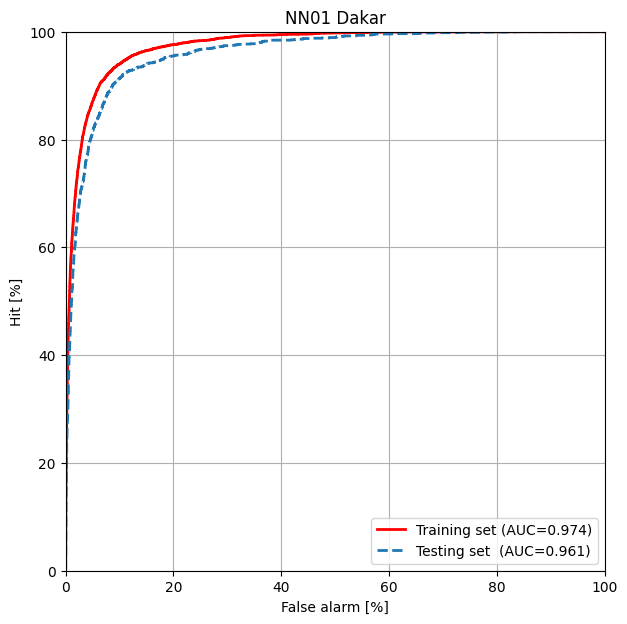

In [307]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train, y_hat_train, color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.title("NN01 Dakar")
plt.legend(loc='lower right');